# Tugas Praktikum Scraping dan Eksplorasi Data

**Nama:** Prima Surya  
**NRP:** Isi NRP Anda  
**Sumber data:** RSSSF  
**Topik:** Hasil Pertandingan Premier League Musim 2019/20–2023/24

In [1]:
import re
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 1. Scraping Dataset

Data diambil dari halaman RSSSF yang berisi hasil pertandingan sepak bola Premier League. Lima musim digunakan agar jumlah data melampaui 1.500 baris.

In [2]:
SUMBER_DATA = {
    "2019/20": "https://www.rsssf.org/tablese/eng2020.html",
    "2020/21": "https://www.rsssf.org/tablese/eng2021.html",
    "2021/22": "https://www.rsssf.org/tablese/eng2022.html",
    "2022/23": "https://www.rsssf.org/tablese/eng2023.html",
    "2023/24": "https://www.rsssf.org/tablese/eng2024.html",
}

SUMBER_DATA

{'2019/20': 'https://www.rsssf.org/tablese/eng2020.html',
 '2020/21': 'https://www.rsssf.org/tablese/eng2021.html',
 '2021/22': 'https://www.rsssf.org/tablese/eng2022.html',
 '2022/23': 'https://www.rsssf.org/tablese/eng2023.html',
 '2023/24': 'https://www.rsssf.org/tablese/eng2024.html'}

In [3]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 Chrome/124.0 Safari/537.36"
    )
}

def ambil_halaman(url):
    response = requests.get(
        url,
        headers=HEADERS,
        timeout=30
    )

    response.raise_for_status()

    print("Status HTTP:", response.status_code)
    print("URL yang diakses:", response.url)

    return response.text

In [4]:
html_contoh = ambil_halaman(SUMBER_DATA["2023/24"])

print("Jumlah karakter HTML:", len(html_contoh))
print(html_contoh[:300])

Status HTTP: 200
URL yang diakses: https://www.rsssf.org/tablese/eng2024.html
Jumlah karakter HTML: 41698
<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<HTML>
<HEAD>
<TITLE>England 2023/24</TITLE>
</HEAD>
<BODY>
<H2>England 2023/24</H2>
<p>
<hr>
<a href="#premier">Premier League</a><br>
<a href="#cups">Cup Tournaments</a><br>
<a href="#champ">Championship</a><br>
<a href="#first">Division 1</a


In [5]:
def ambil_teks_premier_league(html):
    soup = BeautifulSoup(html, "html.parser")

    semua_pre = soup.find_all("pre")

    for elemen_pre in semua_pre:
        teks = elemen_pre.get_text("\n")

        # Bagian pertandingan Premier League memiliki
        # klasemen akhir dan penanda Round 1.
        memiliki_klasemen = re.search(
            r"Final\s+Table",
            teks,
            flags=re.IGNORECASE
        )

        memiliki_pekan_pertama = re.search(
            r"Round\s+1\b",
            teks,
            flags=re.IGNORECASE
        )

        if memiliki_klasemen and memiliki_pekan_pertama:
            return teks

    raise ValueError(
        "Data pertandingan Premier League tidak ditemukan "
        "di dalam elemen <pre>."
    )

### 1.1. Papan Premier League Musin 2020

In [6]:
teks_contoh = ambil_teks_premier_league(html_contoh)

print(teks_contoh[:1500])


Final Table:

 1.Manchester City         38  28  7  3  96-34  91  [C]  Champions
 2.Arsenal                 38  28  5  5  91-29  89
 3.Liverpool               38  24 10  4  86-41  82
 4.Aston Villa             38  20  8 10  76-61  68
 5.Tottenham Hotspur       38  20  6 12  74-61  66
 6.Chelsea                 38  18  9 11  77-63  63
 7.Newcastle United        38  18  6 14  85-62  60
 8.Manchester United       38  18  6 14  57-58  60
 9.West Ham United         38  14 10 14  60-74  52
10.Crystal Palace          38  13 10 15  57-58  49
11.Brighton & Hove Albion  38  12 12 14  55-62  48
12.AFC Bournemouth         38  13  9 16  54-67  48
13.Fulham                  38  13  8 17  55-61  47
14.Wolverhampton Wanderers 38  13  7 18  50-65  46
15.Everton                 38  13  9 16  40-51  40  [-8]
16.Brentford               38  10  9 19  56-65  39
17.Nottingham Forest       38   9  9 20  49-67  32  [-4]
--------------------------------------------------
18.Luton Town              38   6  8 24

In [7]:
def ekstrak_pertandingan(html, musim, url):
    teks = ambil_teks_premier_league(html)
    baris_data = []

    pekan = None
    tanggal = None
    sedang_membaca_pertandingan = False

    pola_pekan = re.compile(
        r"^Round\s+(\d+)\b",
        re.IGNORECASE
    )

    pola_tanggal = re.compile(
        r"^\[([A-Za-z]{3}\s+\d{1,2})\]$"
    )

    pola_klasemen = re.compile(
        r"^(?:Final\s+Table|Table\b|Standings\b|\d+\.\s*[A-Za-z])",
        re.IGNORECASE
    )

    pola_pertandingan = re.compile(
        r"^(?P<kandang>[A-Za-z][A-Za-z .&'’()/\-]*?)"
        r"\s+(?P<gol_kandang>\d+)\s*-\s*"
        r"(?P<gol_tandang>\d+)\s+"
        r"(?P<tandang>[A-Za-z][A-Za-z .&'’()/\-]*?)"
        r"\s*$"
    )

    for baris in teks.splitlines():
        baris = baris.strip()

        if not baris:
            continue

        hasil_pekan = pola_pekan.match(baris)

        if hasil_pekan:
            pekan = int(hasil_pekan.group(1))
            tanggal = None
            sedang_membaca_pertandingan = True
            continue

        if not sedang_membaca_pertandingan:
            continue

        # Klasemen setelah daftar pertandingan bukan data laga.
        if pola_klasemen.match(baris):
            break

        hasil_tanggal = pola_tanggal.match(baris)

        if hasil_tanggal:
            tanggal = hasil_tanggal.group(1)
            continue

        # Hapus catatan di belakang skor, misalnya [replay].
        baris_tanpa_catatan = re.sub(
            r"\s*\[.*$",
            "",
            baris
        ).strip()

        hasil = pola_pertandingan.fullmatch(baris_tanpa_catatan)

        if hasil is None:
            continue

        baris_data.append({
            "musim": musim,
            "pekan": pekan,
            "tanggal_teks": tanggal,
            "tim_kandang": hasil.group("kandang").strip(),
            "tim_tandang": hasil.group("tandang").strip(),
            "gol_kandang": int(hasil.group("gol_kandang")),
            "gol_tandang": int(hasil.group("gol_tandang")),
            "url_sumber": url
        })

    return baris_data

In [8]:
semua_pertandingan = []

for musim, url in SUMBER_DATA.items():
    print(f"Mengambil musim {musim}...")

    try:
        html = ambil_halaman(url)
        data_musim = ekstrak_pertandingan(html, musim, url)

        semua_pertandingan.extend(data_musim)

        print(f"Berhasil: {len(data_musim)} pertandingan")
        time.sleep(1)

    except requests.RequestException as error:
        print(f"Gagal mengambil musim {musim}: {error}")

    except ValueError as error:
        print(f"Gagal membaca musim {musim}: {error}")

Mengambil musim 2019/20...
Status HTTP: 200
URL yang diakses: https://www.rsssf.org/tablese/eng2020.html
Berhasil: 380 pertandingan
Mengambil musim 2020/21...
Status HTTP: 200
URL yang diakses: https://www.rsssf.org/tablese/eng2021.html
Berhasil: 380 pertandingan
Mengambil musim 2021/22...
Status HTTP: 200
URL yang diakses: https://www.rsssf.org/tablese/eng2022.html
Berhasil: 380 pertandingan
Mengambil musim 2022/23...
Status HTTP: 200
URL yang diakses: https://www.rsssf.org/tablese/eng2023.html
Berhasil: 380 pertandingan
Mengambil musim 2023/24...
Status HTTP: 200
URL yang diakses: https://www.rsssf.org/tablese/eng2024.html
Berhasil: 380 pertandingan


### 1.2.Dataset
Dataset dibawah ini merupakan pertandingan Premier League dari tahun 2019 sampai 2024

In [9]:
df_raw = pd.DataFrame(semua_pertandingan)

print("Ukuran dataset mentah:", df_raw.shape)
display(df_raw.head())

Ukuran dataset mentah: (1900, 8)


,musim,pekan,tanggal_teks,tim_kandang,tim_tandang,gol_kandang,gol_tandang,url_sumber
0,2019/20,1,Aug 9,Liverpool,Norwich,4,1,https://www.rsssf.org/tablese/eng2020.html
1,2019/20,1,Aug 10,West Ham,Manchester C,0,5,https://www.rsssf.org/tablese/eng2020.html
2,2019/20,1,Aug 10,Bournemouth,Sheffield U,1,1,https://www.rsssf.org/tablese/eng2020.html
3,2019/20,1,Aug 10,Burnley,Southampton,3,0,https://www.rsssf.org/tablese/eng2020.html
4,2019/20,1,Aug 10,Crystal P,Everton,0,0,https://www.rsssf.org/tablese/eng2020.html


In [10]:
jumlah_per_musim = (
    df_raw.groupby("musim")
    .size()
    .reset_index(name="jumlah_pertandingan")
)

display(jumlah_per_musim)

,musim,jumlah_pertandingan
0,2019/20,380
1,2020/21,380
2,2021/22,380
3,2022/23,380
4,2023/24,380


In [11]:
jumlah_baris, jumlah_kolom = df_raw.shape

print("Jumlah baris:", jumlah_baris)
print("Jumlah kolom:", jumlah_kolom)

if jumlah_baris >= 1500 and jumlah_kolom >= 5:
    print("Dataset memenuhi ketentuan minimal 1.500 baris dan 5 kolom.")
else:
    print("Dataset belum memenuhi ketentuan tugas.")

Jumlah baris: 1900
Jumlah kolom: 8
Dataset memenuhi ketentuan minimal 1.500 baris dan 5 kolom.


In [12]:
df_raw.to_csv(
    "hasil_pertandingan_premier_league_raw.csv",
    index=False
)

print("Data mentah berhasil disimpan.")

Data mentah berhasil disimpan.


In [13]:
df = pd.read_csv("hasil_pertandingan_premier_league_raw.csv")

display(df.head())
print("Ukuran dataset:", df.shape)

print("\nInformasi dataset:")
df.info()

print("\nTipe data:")
display(df.dtypes)

,musim,pekan,tanggal_teks,tim_kandang,tim_tandang,gol_kandang,gol_tandang,url_sumber
0,2019/20,1,Aug 9,Liverpool,Norwich,4,1,https://www.rsssf.org/tablese/eng2020.html
1,2019/20,1,Aug 10,West Ham,Manchester C,0,5,https://www.rsssf.org/tablese/eng2020.html
2,2019/20,1,Aug 10,Bournemouth,Sheffield U,1,1,https://www.rsssf.org/tablese/eng2020.html
3,2019/20,1,Aug 10,Burnley,Southampton,3,0,https://www.rsssf.org/tablese/eng2020.html
4,2019/20,1,Aug 10,Crystal P,Everton,0,0,https://www.rsssf.org/tablese/eng2020.html


Ukuran dataset: (1900, 8)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   musim         1900 non-null   object
 1   pekan         1900 non-null   int64 
 2   tanggal_teks  1850 non-null   object
 3   tim_kandang   1900 non-null   object
 4   tim_tandang   1900 non-null   object
 5   gol_kandang   1900 non-null   int64 
 6   gol_tandang   1900 non-null   int64 
 7   url_sumber    1900 non-null   object
dtypes: int64(3), object(5)
memory usage: 118.9+ KB

Tipe data:


musim           object
pekan            int64
tanggal_teks    object
tim_kandang     object
tim_tandang     object
gol_kandang      int64
gol_tandang      int64
url_sumber      object
dtype: object

## 2. Analisis Statistik dan Kualitas Data

In [14]:
df_bersih = df.copy()

kolom_teks = [
    "musim",
    "tanggal_teks",
    "tim_kandang",
    "tim_tandang",
    "url_sumber"
]

for kolom in kolom_teks:
    df_bersih[kolom] = df_bersih[kolom].astype("string").str.strip()

kolom_numerik = [
    "pekan",
    "gol_kandang",
    "gol_tandang"
]

for kolom in kolom_numerik:
    df_bersih[kolom] = pd.to_numeric(
        df_bersih[kolom],
        errors="coerce"
    )

In [15]:
df_bersih["total_gol"] = (
    df_bersih["gol_kandang"] +
    df_bersih["gol_tandang"]
)

df_bersih["selisih_gol"] = (
    df_bersih["gol_kandang"] -
    df_bersih["gol_tandang"]
)

df_bersih["hasil"] = np.select(
    [
        df_bersih["gol_kandang"] > df_bersih["gol_tandang"],
        df_bersih["gol_kandang"] < df_bersih["gol_tandang"]
    ],
    [
        "Kandang menang",
        "Tandang menang"
    ],
    default="Seri"
)

display(df_bersih.head())

,musim,pekan,tanggal_teks,tim_kandang,tim_tandang,gol_kandang,gol_tandang,url_sumber,total_gol,selisih_gol,hasil
0,2019/20,1,Aug 9,Liverpool,Norwich,4,1,https://www.rsssf.org/tablese/eng2020.html,5,3,Kandang menang
1,2019/20,1,Aug 10,West Ham,Manchester C,0,5,https://www.rsssf.org/tablese/eng2020.html,5,-5,Tandang menang
2,2019/20,1,Aug 10,Bournemouth,Sheffield U,1,1,https://www.rsssf.org/tablese/eng2020.html,2,0,Seri
3,2019/20,1,Aug 10,Burnley,Southampton,3,0,https://www.rsssf.org/tablese/eng2020.html,3,3,Kandang menang
4,2019/20,1,Aug 10,Crystal P,Everton,0,0,https://www.rsssf.org/tablese/eng2020.html,0,0,Seri


### 2.1. Memeriksa Missing Value

In [16]:
missing_value = pd.DataFrame({
    "jumlah_missing": df_bersih.isna().sum(),
    "persentase": (
        df_bersih.isna().mean() * 100
    ).round(2)
})

display(missing_value)

,jumlah_missing,persentase
musim,0,0.00
pekan,0,0.00
tanggal_teks,50,2.63
tim_kandang,0,0.00
tim_tandang,0,0.00
gol_kandang,0,0.00
gol_tandang,0,0.00
url_sumber,0,0.00
total_gol,0,0.00
selisih_gol,0,0.00


tanggal_teks memiliki missing value tetapi tidak perlu dihapus karena skor dan identitas pertandingan masih dapat digunakan untuk analisis.

### 2.2. Memeriksa Data Duplikat

In [17]:
kolom_identitas = [
    "musim",
    "pekan",
    "tim_kandang",
    "tim_tandang"
]

jumlah_duplikat = df_bersih.duplicated(
    subset=kolom_identitas
).sum()

print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 0


In [18]:
kolom_analisis = [
    "gol_kandang",
    "gol_tandang",
    "total_gol",
    "selisih_gol"
]

statistik_numerik = df_bersih[
    kolom_analisis
].describe().T

statistik_numerik["median"] = df_bersih[
    kolom_analisis
].median()

statistik_numerik["modus"] = df_bersih[
    kolom_analisis
].mode().iloc[0]

display(statistik_numerik)

,count,mean,std,min,25%,50%,75%,max,median,modus
gol_kandang,1900.0,1.563158,1.344233,0.0,1.0,1.0,2.0,9.0,1.0,1
gol_tandang,1900.0,1.310000,1.238833,0.0,0.0,1.0,2.0,9.0,1.0,1
total_gol,1900.0,2.873158,1.682927,0.0,2.0,3.0,4.0,9.0,3.0,2
selisih_gol,1900.0,0.253158,1.962421,-9.0,-1.0,0.0,1.0,9.0,0.0,0


In [19]:
distribusi_hasil = (
    df_bersih["hasil"]
    .value_counts()
    .reset_index()
)

distribusi_hasil.columns = ["hasil", "jumlah"]

display(distribusi_hasil)

,hasil,jumlah
0,Kandang menang,838
1,Tandang menang,630
2,Seri,432


### 2.3.Memeriksa Data Outlier

In [20]:
def deteksi_outlier_iqr(data, kolom):
    q1 = data[kolom].quantile(0.25)
    q3 = data[kolom].quantile(0.75)
    iqr = q3 - q1

    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr

    outlier = data[
        (data[kolom] < batas_bawah) |
        (data[kolom] > batas_atas)
    ]

    return q1, q3, batas_bawah, batas_atas, outlier

In [21]:
q1, q3, batas_bawah, batas_atas, outlier_total_gol = (
    deteksi_outlier_iqr(df_bersih, "total_gol")
)

print("Q1:", q1)
print("Q3:", q3)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)
print("Jumlah outlier:", len(outlier_total_gol))

display(
    outlier_total_gol[
        [
            "musim",
            "tim_kandang",
            "tim_tandang",
            "gol_kandang",
            "gol_tandang",
            "total_gol"
        ]
    ].sort_values("total_gol", ascending=False)
)

Q1: 2.0
Q3: 4.0
Batas bawah: -1.0
Batas atas: 7.0
Jumlah outlier: 15


,musim,tim_kandang,tim_tandang,gol_kandang,gol_tandang,total_gol
90,2019/20,Southampton,Leicester,0,9,9
592,2020/21,Manchester U,Southampton,9,0,9
419,2020/21,Aston Villa,Liverpool,7,2,9
941,2021/22,Manchester C,Leicester,6,3,9
1174,2022/23,Liverpool,Bournemouth,9,0,9
1227,2022/23,Manchester C,Manchester U,6,3,9
54,2019/20,Manchester C,Watford,8,0,8
516,2020/21,Manchester U,Leeds,6,2,8
369,2019/20,Liverpool,Chelsea,5,3,8
1214,2022/23,Tottenham,Leicester,6,2,8


## 3. Visualisasi Data

### 3.1. Histogram Distribusi Total Gol dalam Pertandingan 

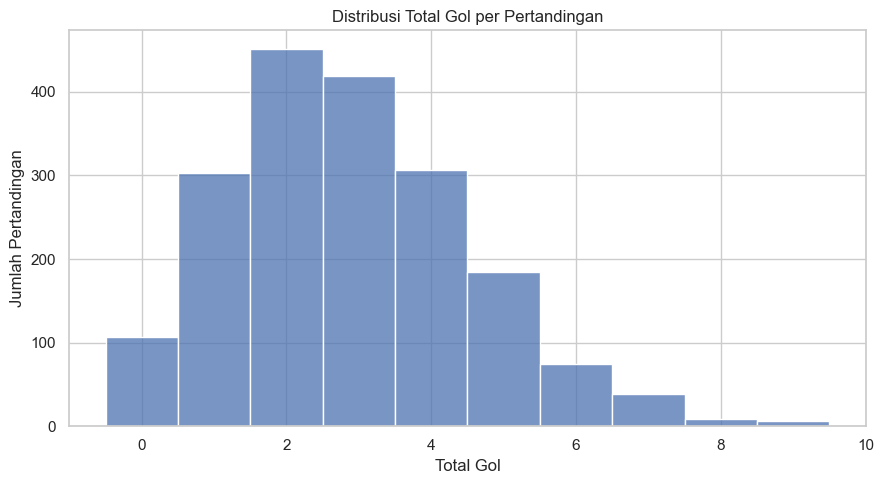

Total gol yang paling sering muncul adalah 2 gol. Rata-rata total gol setiap pertandingan adalah 2.87 gol.


In [22]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_bersih,
    x="total_gol",
    bins=range(
        int(df_bersih["total_gol"].max()) + 2
    ),
    discrete=True
)

plt.title("Distribusi Total Gol per Pertandingan")
plt.xlabel("Total Gol")
plt.ylabel("Jumlah Pertandingan")
plt.tight_layout()
plt.show()
modus_total_gol = df_bersih["total_gol"].mode().iloc[0]
rata_total_gol = df_bersih["total_gol"].mean()

print(
    f"Total gol yang paling sering muncul adalah {modus_total_gol} gol. "
    f"Rata-rata total gol setiap pertandingan adalah "
    f"{rata_total_gol:.2f} gol."
)

### 3.2. Diagram Batang Hasil Pertandingan

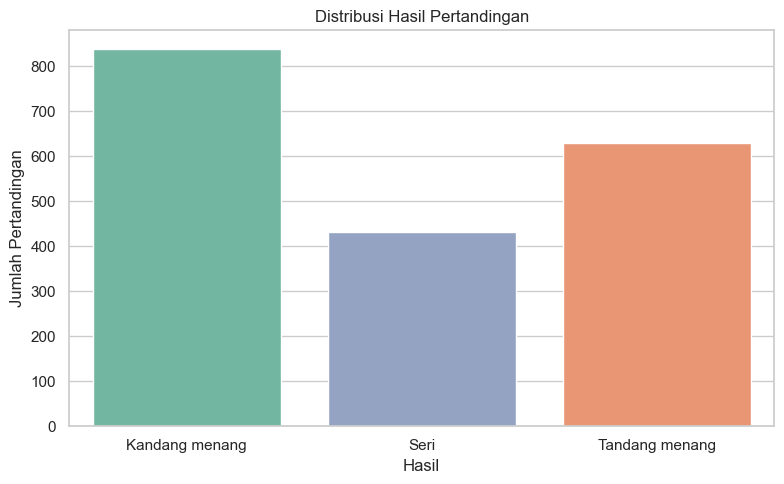

hasil
Kandang menang    44.11
Tandang menang    33.16
Seri              22.74
Name: proportion, dtype: float64

In [23]:
urutan_hasil = [
    "Kandang menang",
    "Seri",
    "Tandang menang"
]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_bersih,
    x="hasil",
    order=urutan_hasil,
    hue="hasil",
    palette="Set2",
    legend=False
)

plt.title("Distribusi Hasil Pertandingan")
plt.xlabel("Hasil")
plt.ylabel("Jumlah Pertandingan")
plt.tight_layout()
plt.show()
persentase_hasil = (
    df_bersih["hasil"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(persentase_hasil)

### 3.3. Boxplot Distribusi Total Gol Pertandingan

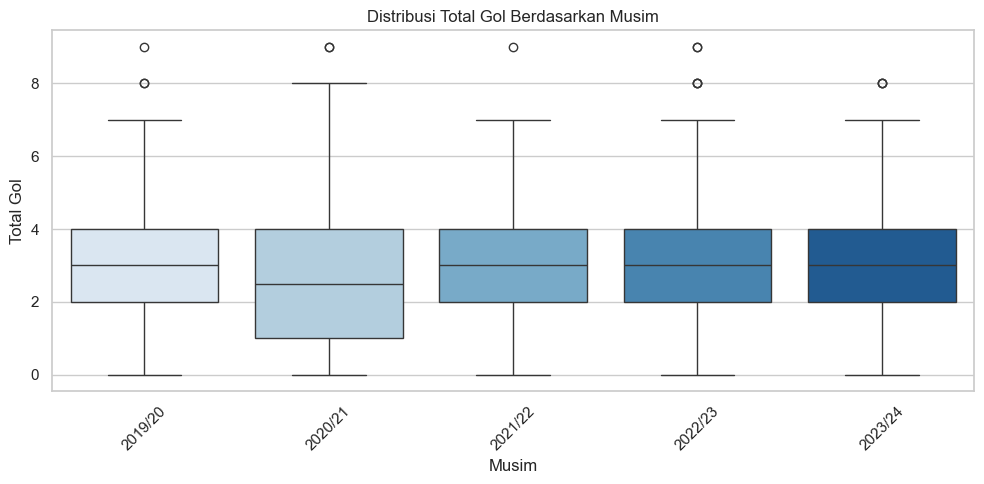

musim
2023/24    3.278947
2022/23    2.852632
2021/22    2.818421
2019/20    2.721053
2020/21    2.694737
Name: total_gol, dtype: float64

Musim dengan rata-rata total gol tertinggi adalah 2023/24, yaitu 3.28 gol per pertandingan.


In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_bersih,
    x="musim",
    y="total_gol",
    hue="musim",
    palette="Blues",
    legend=False
)

plt.title("Distribusi Total Gol Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Total Gol")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rata_gol_per_musim = (
    df_bersih.groupby("musim")["total_gol"]
    .mean()
    .sort_values(ascending=False)
)

display(rata_gol_per_musim)

musim_tertinggi = rata_gol_per_musim.index[0]
nilai_tertinggi = rata_gol_per_musim.iloc[0]

print(
    f"Musim dengan rata-rata total gol tertinggi adalah "
    f"{musim_tertinggi}, yaitu {nilai_tertinggi:.2f} "
    f"gol per pertandingan."
)

### 3.4. Scatterplot Gol Kandang dan Tandang

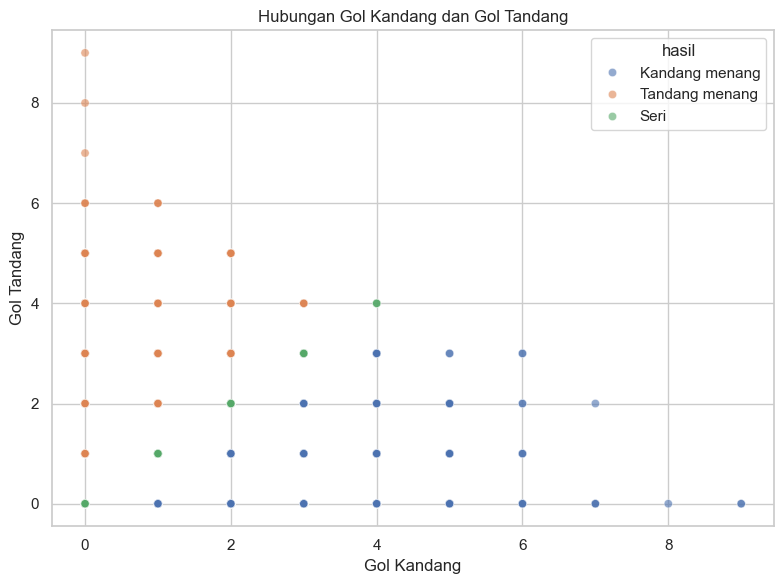

In [25]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_bersih,
    x="gol_kandang",
    y="gol_tandang",
    hue="hasil",
    alpha=0.6
)

plt.title("Hubungan Gol Kandang dan Gol Tandang")
plt.xlabel("Gol Kandang")
plt.ylabel("Gol Tandang")
plt.tight_layout()
plt.show()

### 3.5. Correlation Heatmap

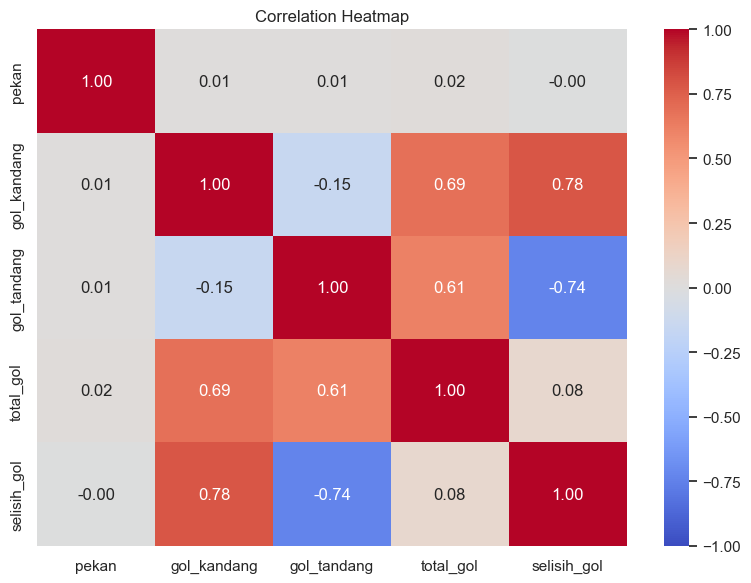

In [26]:
kolom_korelasi = [
    "pekan",
    "gol_kandang",
    "gol_tandang",
    "total_gol",
    "selisih_gol"
]

matriks_korelasi = df_bersih[
    kolom_korelasi
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriks_korelasi,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [27]:
df_bersih.to_csv(
    "hasil_pertandingan_premier_league_bersih.csv",
    index=False
)

print("Data bersih berhasil disimpan.")
print("Ukuran akhir dataset:", df_bersih.shape)

Data bersih berhasil disimpan.
Ukuran akhir dataset: (1900, 11)


## 4. Kesimpulan

Dataset hasil scraping berisi pertandingan Premier League selama lima musim.
Dataset telah memenuhi ketentuan minimal 1.500 baris dan 5 kolom.

Analisis dilakukan terhadap jumlah gol, hasil pertandingan, perbedaan antar
musim, missing value, data duplikat, dan outlier. Outlier berupa pertandingan
dengan jumlah gol tinggi dipertahankan karena merupakan data pertandingan yang
valid dan memiliki nilai informasi.

Berdasarkan visualisasi, dapat diketahui hasil pertandingan yang paling sering
terjadi, rata-rata gol setiap musim, serta pola hubungan antara gol kandang dan
gol tandang.